<a href="https://colab.research.google.com/github/2403a52009-bot/ML/blob/main/ml_Asn_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 11: AdaBoost Implementation  

Dataset: Breast Cancer Wisconsin (Kaggle)

Objective:
Compare classification performance between a single Decision Tree and an AdaBoost ensemble.


## STEP 1 — Install and Import Libraries

In [1]:

# Install Kaggle API (only needed in Colab)
!pip install kaggle --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve


## STEP 2 — Download Dataset from Kaggle

In [2]:

# Upload kaggle.json if running in Colab
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d uciml/breast-cancer-wisconsin-data
!unzip -o breast-cancer-wisconsin-data.zip


Saving data.csv to data.csv
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open breast-cancer-wisconsin-data.zip, breast-cancer-wisconsin-data.zip.zip or breast-cancer-wisconsin-da

## STEP 3 — Load Dataset

In [3]:

df = pd.read_csv("data.csv")
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



The dataset contains measurements of cell nuclei from breast mass images.
Target variable:
- M = Malignant
- B = Benign


## STEP 4 — Data Preprocessing

In [4]:

df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  # M=1, B=0

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]


## STEP 5 — Train/Test Split (80/20)

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## STEP 6 — Train Decision Tree Classifier

In [6]:

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)
dt_probs = dt.predict_proba(X_test)[:,1]

dt_accuracy = accuracy_score(y_test, dt_preds)
dt_auc = roc_auc_score(y_test, dt_probs)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree ROC-AUC:", dt_auc)


Decision Tree Accuracy: 0.9473684210526315
Decision Tree ROC-AUC: 0.9439895185063871


## STEP 7 — Train AdaBoost Classifier

In [7]:

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

ada_preds = ada.predict(X_test)
ada_probs = ada.predict_proba(X_test)[:,1]

ada_accuracy = accuracy_score(y_test, ada_preds)
ada_auc = roc_auc_score(y_test, ada_probs)

print("AdaBoost Accuracy:", ada_accuracy)
print("AdaBoost ROC-AUC:", ada_auc)


AdaBoost Accuracy: 0.9736842105263158
AdaBoost ROC-AUC: 0.9944317065181788


## STEP 8 — ROC Curve Comparison

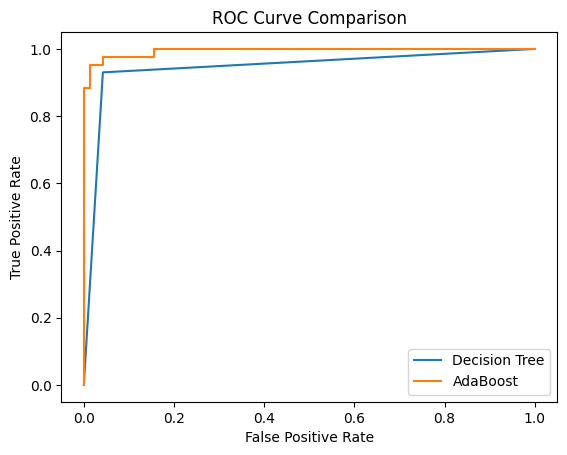

In [8]:

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_probs)

plt.figure()
plt.plot(dt_fpr, dt_tpr, label="Decision Tree")
plt.plot(ada_fpr, ada_tpr, label="AdaBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()



## STEP 9 — Conclusion

AdaBoost combines multiple weak decision trees to form a stronger classifier.
It focuses on correcting errors made by previous models during training.
As a result, AdaBoost generally achieves higher accuracy and ROC-AUC compared
to a single Decision Tree model.
